In [1]:
import pandas as pd

# EXPLORATION

In [2]:
df = pd.read_csv("ventes_boutique.csv")
df.head()

,id_commande,date_commande,client_id,ville_client,produit,categorie,quantite,prix_unitaire,note_satisfaction
0,CMD1240,2024-09-22,CL1021,Aneho,Sac a dos,Accessoire,3.0,71.52,4.0
1,CMD1060,2024-12-07,CL1083,Sokode,Jean,Bas,2.0,60.19,4.0
2,CMD1402,2024-09-10,CL1130,Sokode,Casquette,Accessoire,5.0,11.68,5.0
3,CMD1159,2024-03-20,CL1167,Sokode,Chaussettes,Bas,4.0,8.18,4.0
4,CMD1051,2024-03-20,CL1041,NaN,jean,Bas,4.0,47.38,3.0


In [3]:
df.shape

(490, 9)

In [4]:
df.dtypes

id_commande           object
date_commande         object
client_id             object
ville_client          object
produit               object
categorie             object
quantite             float64
prix_unitaire        float64
note_satisfaction    float64
dtype: object

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 490 entries, 0 to 489
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id_commande        490 non-null    object 
 1   date_commande      490 non-null    object 
 2   client_id          490 non-null    object 
 3   ville_client       475 non-null    object 
 4   produit            490 non-null    object 
 5   categorie          490 non-null    object 
 6   quantite           482 non-null    float64
 7   prix_unitaire      475 non-null    float64
 8   note_satisfaction  445 non-null    float64
dtypes: float64(3), object(6)
memory usage: 34.6+ KB


In [6]:
df.isna().sum()

id_commande           0
date_commande         0
client_id             0
ville_client         15
produit               0
categorie             0
quantite              8
prix_unitaire        15
note_satisfaction    45
dtype: int64

In [7]:
df.duplicated().sum()

np.int64(7)

# NETTOYAGE 

### Suppression des lignes dupliquées

In [8]:
df = df.drop_duplicates()
df.duplicated().sum()

np.int64(0)

### Nettoyez la colonne produit : supprimez les espaces inutiles et harmonisez la casse (par exemple tout mettre avec une majuscule initiale)

In [9]:
df['produit'] = df['produit'].str.strip()
df['produit'] = df['produit'].str.title()
display(df['produit'])

0        Sac A Dos
1             Jean
2        Casquette
3      Chaussettes
4             Jean
          ...     
485    Chaussettes
486          Veste
487        T-Shirt
488      Sac A Dos
489           Jean
Name: produit, Length: 483, dtype: object

### Conversion de la date

In [10]:
df["date_commande"] = pd.to_datetime(df["date_commande"], dayfirst=False, errors="coerce")

### Traitez les valeurs manquantes de prix_unitaire en les remplacant par la mediane du produit concerne 

In [11]:
df['prix_unitaire'] = df['prix_unitaire'].fillna(
    df.groupby('produit')['prix_unitaire'].transform('median')
)

In [12]:
df.isna().sum()

id_commande           0
date_commande        10
client_id             0
ville_client         15
produit               0
categorie             0
quantite              8
prix_unitaire         0
note_satisfaction    44
dtype: int64

### Traitez les valeurs manquantes de quantite en les remplacant par 1 (hypothese : une commande sans quantite renseignee correspond a 1 article)

In [13]:
df['quantite'] = df['quantite'].fillna(1)

In [14]:
df.isna().sum()

id_commande           0
date_commande        10
client_id             0
ville_client         15
produit               0
categorie             0
quantite              0
prix_unitaire         0
note_satisfaction    44
dtype: int64

### Traitez les valeurs manquantes de ville_client en les remplacant par la chaine "Inconnue"

In [15]:
df['ville_client'] = df['ville_client'].fillna("Inconnue")

In [16]:
df.isna().sum()

id_commande           0
date_commande        10
client_id             0
ville_client          0
produit               0
categorie             0
quantite              0
prix_unitaire         0
note_satisfaction    44
dtype: int64

###  Detectez les valeurs aberrantes

In [17]:
df.describe()

,date_commande,quantite,prix_unitaire,note_satisfaction
count,473,483.000000,483.000000,439.000000
mean,2024-07-11 23:14:20.042283520,2.345756,54.984679,3.630979
min,2024-01-01 00:00:00,1.000000,5.020000,1.000000
25%,2024-04-20 00:00:00,1.000000,17.870000,3.000000
50%,2024-07-11 00:00:00,2.000000,44.620000,4.000000
75%,2024-10-11 00:00:00,3.000000,68.010000,5.000000
max,2024-12-30 00:00:00,5.000000,2002.350000,5.000000
std,NaN,1.352160,102.944502,1.258958


In [18]:
outliers = df[df['prix_unitaire'] > 300]
display(outliers)

,id_commande,date_commande,client_id,ville_client,produit,categorie,quantite,prix_unitaire,note_satisfaction
115,CMD1450,2024-06-04,CL1062,Lome,Sac A Dos,Accessoire,2.0,457.20,5.0
376,CMD1054,2024-04-26,CL1006,Lome,Veste,Haut,5.0,2002.35,3.0
475,CMD1042,2024-06-27,CL1062,Lome,Jean,Bas,2.0,807.30,2.0


In [19]:
# Calcul de la médiane par produit
mediane_par_produit = df.groupby("produit")["prix_unitaire"].median()

# Remplacer les outliers par la médiane correspondante
df.loc[df["prix_unitaire"] > 300, "prix_unitaire"] = (
    df.loc[df["prix_unitaire"] > 300, "produit"].map(mediane_par_produit)
)

In [20]:
df[df['prix_unitaire'] > 300].value_counts()

Series([], Name: count, dtype: int64)

**La colonne note_satisfaction garde volontairement ses valeurs manquantes**

# AGREGATION

### Creez une colonne montant_total = quantite × prix_unitaire

In [21]:
df['montant_total'] = df['quantite'] * df['prix_unitaire']

In [22]:
df['montant_total'].head()

0    214.56
1    120.38
2     58.40
3     32.72
4    189.52
Name: montant_total, dtype: float64

###  A partir de date_commande, creez deux nouvelles colonnes : mois (numero du mois) et jour_semaine (nom du jour)

In [23]:
df['mois'] = df['date_commande'].dt.month
df['jour_semaine'] = df['date_commande'].dt.day_name()
df[['mois', 'jour_semaine']]

,mois,jour_semaine
0,9.0,Sunday
1,12.0,Saturday
2,9.0,Tuesday
3,3.0,Wednesday
4,3.0,Wednesday
...,...,...
485,12.0,Monday
486,5.0,Saturday
487,1.0,Thursday
488,2.0,Saturday


### Calculez le chiffre d'affaires total (somme de montant_total) par categorie de produit, trie du plus grand au plus petit

In [24]:
ca_total = df.groupby("categorie")['montant_total'].sum().sort_values(ascending = False)
ca_total

categorie
Haut          22454.815
Chaussures    11074.390
Accessoire     9863.710
Bas            9369.325
Name: montant_total, dtype: float64

### Calculez le chiffre d'affaires total par mois

In [25]:
ca_mois = df.groupby('mois')['montant_total'].sum()
ca_mois.sort_values(ascending=False)

mois
10.0    6370.495
12.0    5332.900
6.0     4774.455
9.0     4608.810
1.0     4198.290
5.0     4143.795
4.0     4108.680
3.0     3974.150
11.0    3781.880
2.0     3731.240
7.0     3313.785
8.0     3109.500
Name: montant_total, dtype: float64

### Calculez, pour chaque produit, la quantite moyenne commandee et la note de satisfaction moyenne

In [26]:
enquete = df.groupby('produit').agg(
    quant_moy = ('quantite', 'mean'),
    note_moy = ('note_satisfaction', 'mean')
)
enquete

,quant_moy,note_moy
produit,,
Casquette,2.422222,3.682927
Chaussettes,2.530303,3.600000
Jean,2.272727,3.467742
Pull,2.453125,3.457627
Sac A Dos,2.366667,3.888889
Sneakers,2.101449,3.507692
T-Shirt,2.309091,3.862745
Veste,2.344828,3.673077


###  Construisez un tableau croise (pivot_table) montrant le chiffre d'affaires total par ville et par categorie

In [27]:
ca_final = df.pivot_table(values='montant_total', index='ville_client', columns='categorie', aggfunc='sum')
ca_final

categorie,Accessoire,Bas,Chaussures,Haut
ville_client,,,,
Aneho,803.51,943.120,1518.96,947.660
Atakpame,1063.76,517.850,515.31,1385.750
Dapaong,62.53,858.385,758.81,769.800
Inconnue,546.91,348.400,115.04,146.730
Kara,694.15,926.375,1440.60,3739.750
Kpalime,782.17,180.500,1178.47,1568.090
Lome,3453.70,3126.805,2904.42,9228.155
Sokode,1586.86,1677.960,1466.06,3205.870
Tsevie,870.12,789.930,1176.72,1463.010


### Identifiez le top 5 des clients (client_id) par montant total depense

In [28]:
top = df['montant_total'].sort_values(ascending=False)
top.head()

228    610.75
377    588.64
282    551.92
121    522.48
376    514.55
Name: montant_total, dtype: float64

# VISUALISATION

### Tracez la courbe (plt.plot) du chiffre d'affaires total par mois (mois en abscisse, CA en ordonnee)

In [29]:
import matplotlib.pyplot as plt

In [30]:
df.head()

,id_commande,date_commande,client_id,ville_client,produit,categorie,quantite,prix_unitaire,note_satisfaction,montant_total,mois,jour_semaine
0,CMD1240,2024-09-22,CL1021,Aneho,Sac A Dos,Accessoire,3.0,71.52,4.0,214.56,9.0,Sunday
1,CMD1060,2024-12-07,CL1083,Sokode,Jean,Bas,2.0,60.19,4.0,120.38,12.0,Saturday
2,CMD1402,2024-09-10,CL1130,Sokode,Casquette,Accessoire,5.0,11.68,5.0,58.40,9.0,Tuesday
3,CMD1159,2024-03-20,CL1167,Sokode,Chaussettes,Bas,4.0,8.18,4.0,32.72,3.0,Wednesday
4,CMD1051,2024-03-20,CL1041,Inconnue,Jean,Bas,4.0,47.38,3.0,189.52,3.0,Wednesday


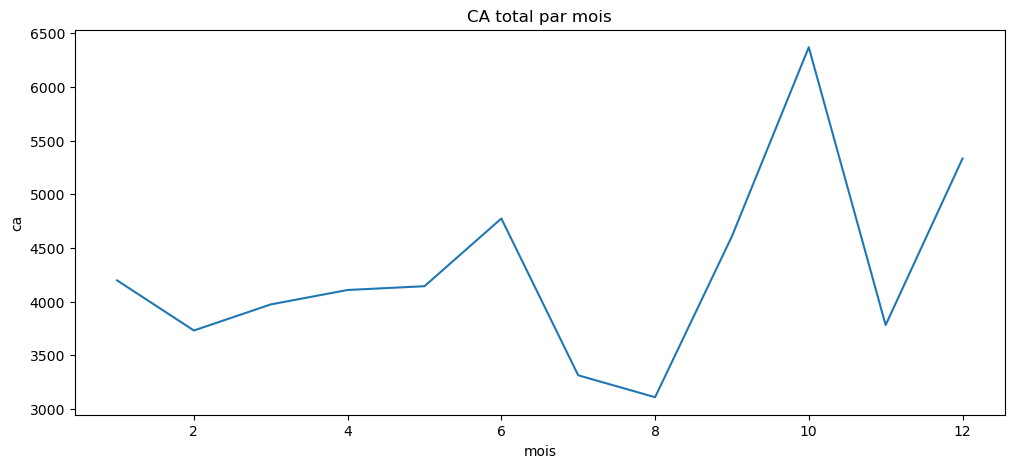

In [31]:
plt.figure(figsize=(12,5))

plt.plot(ca_mois)
plt.xlabel("mois")
plt.ylabel("ca")
plt.title("CA total par mois")

plt.show()

### Tracez un diagramme en barres (plt.bar) du chiffre d'affaires total par categorie de produit

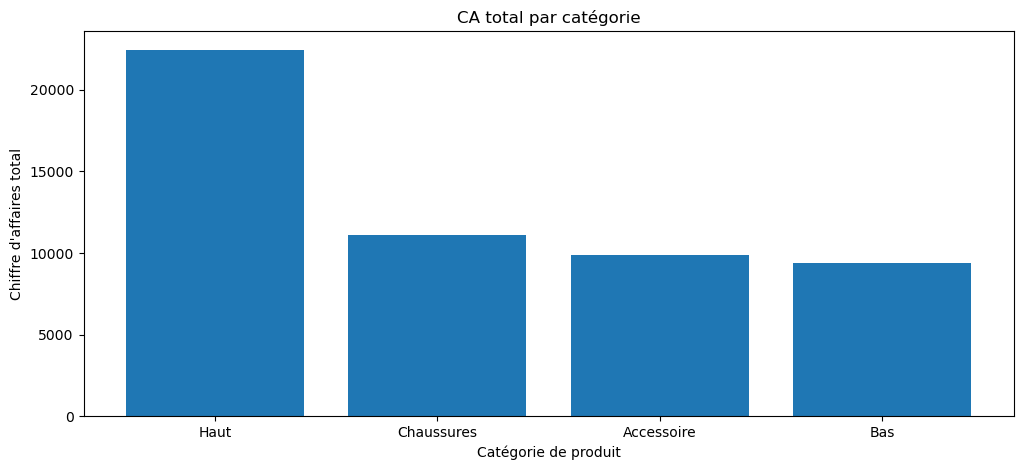

In [32]:
plt.figure(figsize=(12,5))

plt.bar(ca_total.index, ca_total.values)
plt.xlabel("Catégorie de produit")
plt.ylabel("Chiffre d'affaires total")
plt.title("CA total par catégorie")

plt.show()

### Tracez un diagramme en barres du nombre de commandes par ville (hors "Inconnue")

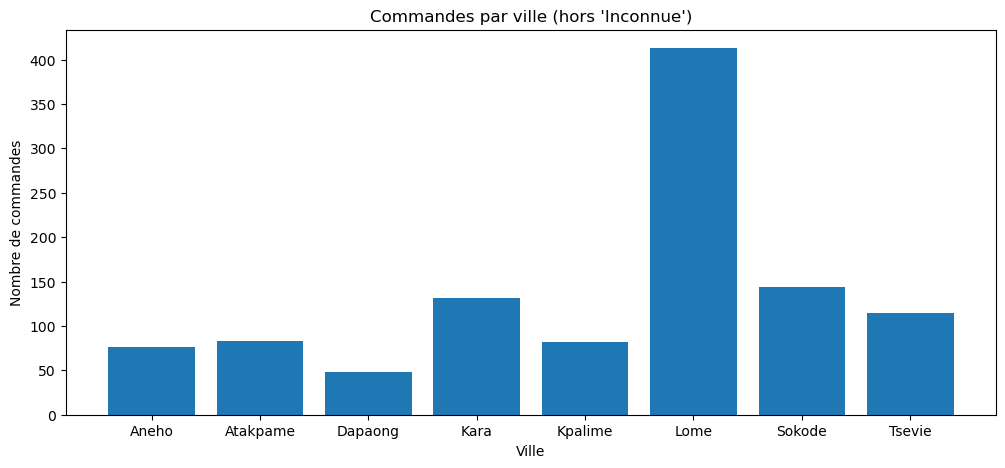

In [33]:
# Filtrer les villes valides
df_filtre = df[df["ville_client"] != "Inconnue"]

# Agréger le nombre de commandes par ville
commandes_par_ville = df_filtre.groupby("ville_client")["quantite"].sum()

# Tracé du diagramme en barres
plt.figure(figsize=(12,5))
plt.bar(commandes_par_ville.index, commandes_par_ville.values)
plt.xlabel("Ville")
plt.ylabel("Nombre de commandes")
plt.title("Commandes par ville (hors 'Inconnue')")

plt.show()

###  Sur une meme figure, superposez deux courbes representant le CA mensuel de deux categories differentes

In [34]:
df['categorie'].value_counts()

categorie
Haut          177
Bas           132
Accessoire    105
Chaussures     69
Name: count, dtype: int64

In [38]:
haut = df[df['categorie'] == "Haut"]
ca_haut = haut.groupby('mois')['montant_total'].sum()

In [39]:
bas = df[df['categorie'] == "Bas"]
ca_bas = bas.groupby('mois')['montant_total'].sum()

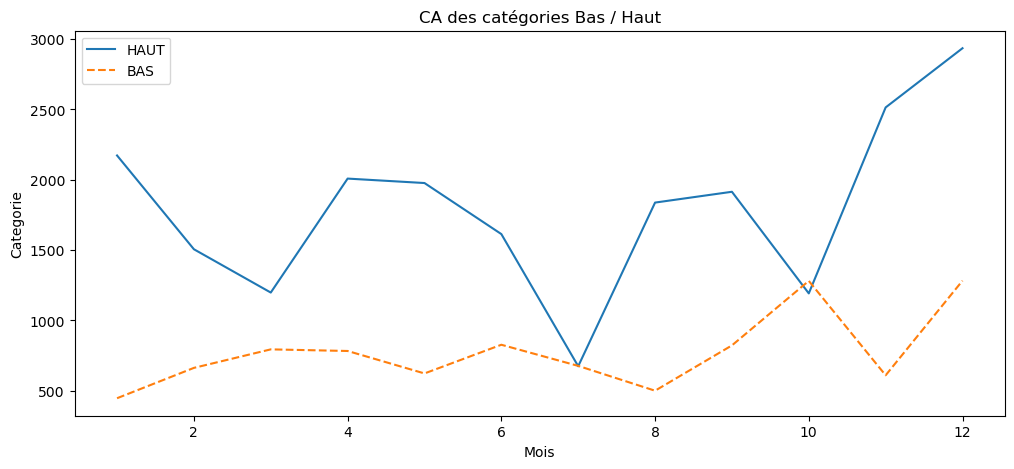

In [40]:
plt.figure(figsize=(12,5))

plt.plot(ca_haut.index, ca_haut.values, label="HAUT")
plt.plot(ca_bas.index, ca_bas.values, label="BAS", ls = '--')
plt.xlabel("Mois")
plt.ylabel("Categorie")
plt.title('CA des catégories Bas / Haut')
plt.legend()

plt.show()

# CONCLUSION

**La catégorie qui genere le plus haut CA est "Haut" et celle qui genere le plus bas CA est "Bas"**

**Le mois avec le plus haut CA est Octobre(10)**

**La satisfaction moyenne est comprise entre 3.457627 et 3.888889**